<a href="https://colab.research.google.com/github/m1deey/Credit_Card_Customer_Segmentation/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
df=pd.read_csv("CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [21]:
df.shape

(8950, 18)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [59]:
import numpy as np

df["ONEOFF_PURCHASE_PERCENT"] = np.where(
    df["PURCHASES"] > 0,
    df["ONEOFF_PURCHASES"] / df["PURCHASES"],
    0
)

df["INSTALLMENT_PURCHASE_PERCENT"] = np.where(
    df["PURCHASES"] > 0,
    df["INSTALLMENTS_PURCHASES"] / df["PURCHASES"],
    0
)

In [79]:
X = df[[
    "BALANCE",
    "PURCHASES",

    "PURCHASES_FREQUENCY",
    "PURCHASES_TRX",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "PRC_FULL_PAYMENT",

]]

In [80]:
X=X.dropna()

In [81]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BALANCE              8949 non-null   float64
 1   PURCHASES            8949 non-null   float64
 2   PURCHASES_FREQUENCY  8949 non-null   float64
 3   PURCHASES_TRX        8949 non-null   int64  
 4   CREDIT_LIMIT         8949 non-null   float64
 5   PAYMENTS             8949 non-null   float64
 6   PRC_FULL_PAYMENT     8949 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 559.3 KB


In [82]:
X.head()

,BALANCE,PURCHASES,PURCHASES_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
0,40.900749,95.40,0.166667,2,1000.0,201.802084,0.000000
1,3202.467416,0.00,0.000000,0,7000.0,4103.032597,0.222222
2,2495.148862,773.17,1.000000,12,7500.0,622.066742,0.000000
3,1666.670542,1499.00,0.083333,1,7500.0,0.000000,0.000000
4,817.714335,16.00,0.083333,1,1200.0,678.334763,0.000000


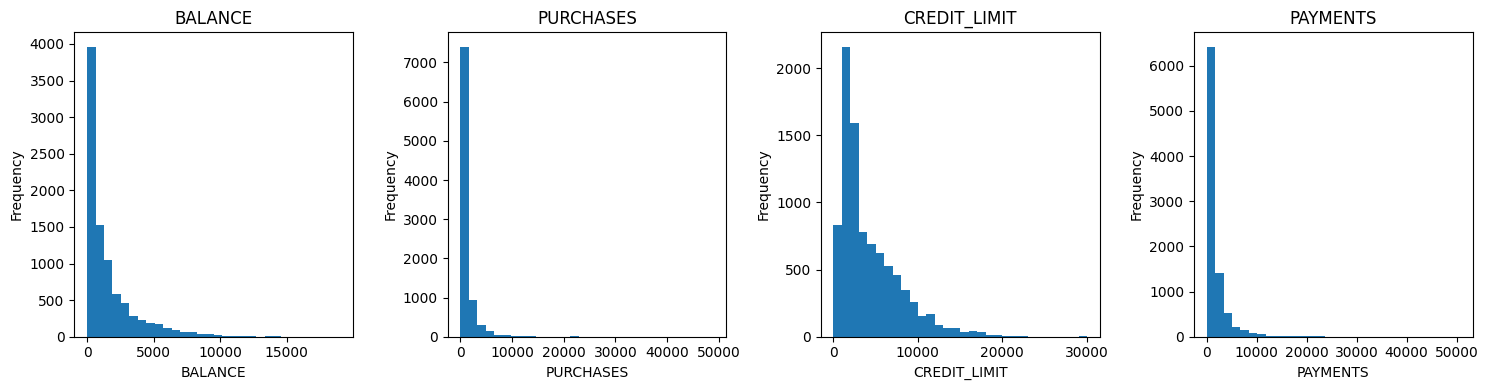

In [83]:
import matplotlib.pyplot as plt

cols = ["BALANCE","PURCHASES", "CREDIT_LIMIT", "PAYMENTS"]

plt.figure(figsize=(15,4))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 4, i)
    plt.hist(df[col], bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled= pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X_scaled.head()

,BALANCE,PURCHASES,PURCHASES_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
0,-0.732054,-0.424934,-0.806649,-0.511381,-0.960380,-0.529026,-0.525588
1,0.786858,-0.469584,-1.221928,-0.591841,0.688601,0.818546,0.234159
2,0.447041,-0.107716,1.269742,-0.109082,0.826016,-0.383857,-0.525588
3,0.049015,0.231995,-1.014290,-0.551611,0.826016,-0.598733,-0.525588
4,-0.358849,-0.462095,-1.014290,-0.551611,-0.905414,-0.364421,-0.525588


In [85]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=10)
clusters = dbscan.fit_predict(X_scaled)
X["DBSCAN_Cluster"] = clusters
X["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,8592
-1,357


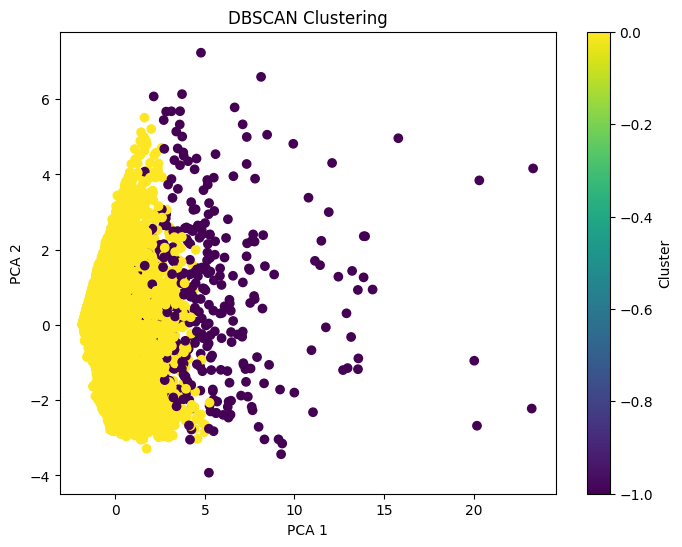

In [86]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()

In [87]:
X.groupby("DBSCAN_Cluster").mean().round(2)

,BALANCE,PURCHASES,PURCHASES_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
DBSCAN_Cluster,,,,,,,
-1,4452.80,6829.78,0.78,75.06,11443.00,10269.42,0.27
0,1444.64,761.23,0.48,12.20,4205.74,1378.66,0.15


Cluster 0 (Regular Customers): Typical credit card users with moderate spending, lower balances, and average payment behavior.
Noise (-1) (High-Value Customers / Outliers): Customers with significantly higher spending, larger balances, higher credit limits, and much larger payments. They represent a small group with exceptional financial activity that differs greatly from the majority.

In [90]:
cluster_names = {
    0: "Regular Customers",
    -1: "High-Value Customers (Outliers)"
}

X["DBSCAN_Label"] = X["DBSCAN_Cluster"].map(cluster_names)
X.head(7)

,BALANCE,PURCHASES,PURCHASES_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,DBSCAN_Cluster,DBSCAN_Label
0,40.900749,95.40,0.166667,2,1000.0,201.802084,0.000000,0,Regular Customers
1,3202.467416,0.00,0.000000,0,7000.0,4103.032597,0.222222,0,Regular Customers
2,2495.148862,773.17,1.000000,12,7500.0,622.066742,0.000000,0,Regular Customers
3,1666.670542,1499.00,0.083333,1,7500.0,0.000000,0.000000,0,Regular Customers
4,817.714335,16.00,0.083333,1,1200.0,678.334763,0.000000,0,Regular Customers
5,1809.828751,1333.28,0.666667,8,1800.0,1400.057770,0.000000,0,Regular Customers
6,627.260806,7091.01,1.000000,64,13500.0,6354.314328,1.000000,-1,High-Value Customers (Outliers)


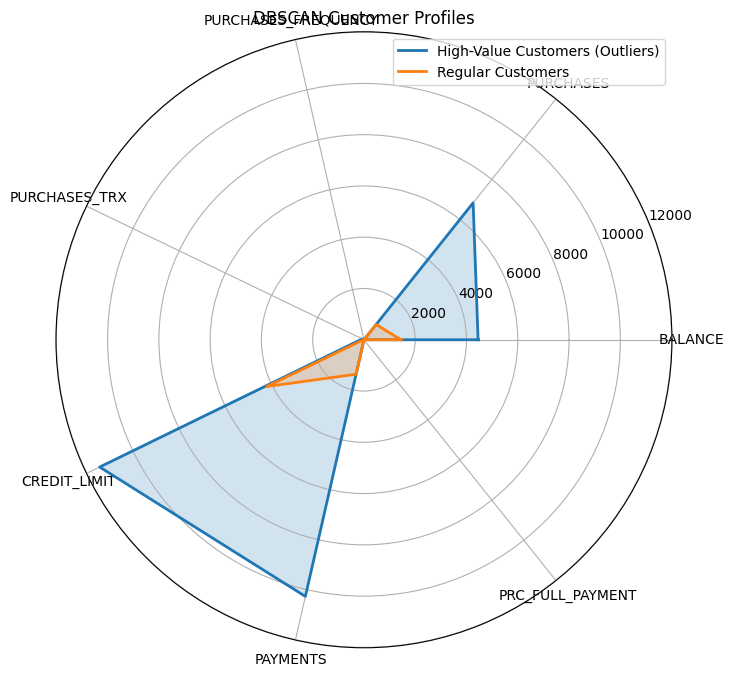

In [92]:
from math import pi
import matplotlib.pyplot as plt

categories = profile.columns.tolist()
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for idx, row in profile.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=idx)
    ax.fill(angles, values, alpha=0.2)

plt.xticks(angles[:-1], categories)
plt.title("DBSCAN Customer Profiles")
plt.legend(loc="upper right")
plt.show()